In [1]:
import sys
#lets you access python's runtime environment
from pathlib import Path
#sys.path is a built in variable in the sys module and contains a list of directories that is seached through when you do an import
#so we are appending the src directory to that
sys.path.append(str(Path().resolve().parent / "src"))
import config

import matplotlib.pyplot as plt
import pandas as pd

df_path= config.PROJECT_ROOT/ "data" / "cleaned.csv"
panel_data_path = config.PROJECT_ROOT/ "data" / "panel_data.csv"
panel_data = pd.read_csv(panel_data_path)
df= pd.read_csv(df_path)

C:\Users\bnpar\AppData\Local\Temp\ipykernel_43848\553632145.py:15: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(df_path)


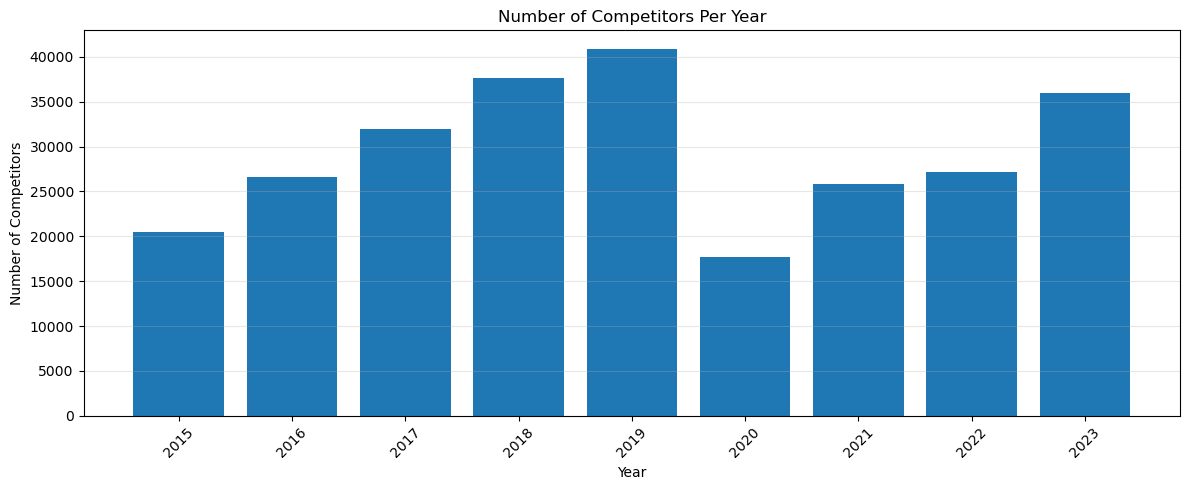

In [2]:
train_val = panel_data.loc[panel_data['Year'] <= 2023]


competitors_per_year = train_val.groupby('Year')['Name'].nunique()

plt.figure(figsize=(12, 5))
plt.bar(competitors_per_year.index, competitors_per_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Competitors')
plt.title('Number of Competitors Per Year')
plt.xticks(competitors_per_year.index, rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

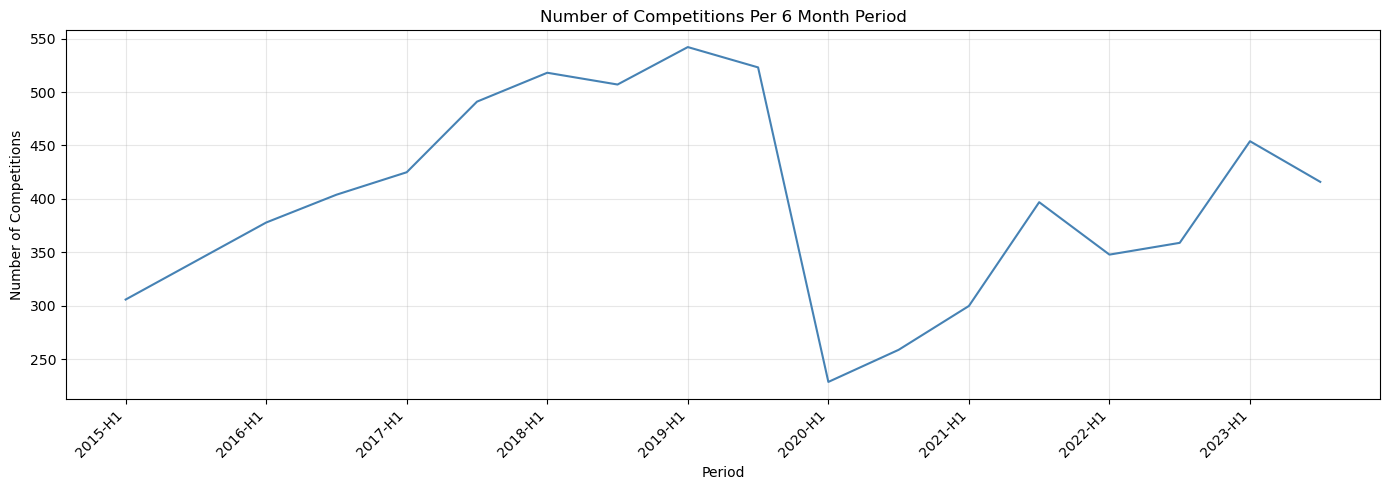

In [8]:

df['Date'] = pd.to_datetime(df['Date'])
df = df.loc[df['Date'] < '2024-01-01']
df['HalfYear'] = df['Date'].dt.year.astype(str) + '-H' + ((df['Date'].dt.month > 6).astype(int) + 1).astype(str)

competitions_per_period = (
    df.groupby('HalfYear')[['Date', 'MeetName']]
    .apply(lambda x: x.drop_duplicates().shape[0])
)

plt.figure(figsize=(14, 5))
plt.plot(competitions_per_period.index, competitions_per_period.values, color='steelblue')
plt.xticks(competitions_per_period.index[::2], rotation=45, ha='right')
plt.xlabel('Period')
plt.ylabel('Number of Competitions')
plt.title('Number of Competitions Per 6 Month Period')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()